In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("data.csv")

In [23]:
df.head(5)

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [25]:
df.describe()

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
count,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,...,246945.0,246945.0,246945.0,246945.0,246945.000000,246945.0,246945.0,246945.0,246945.000000,246945.0
mean,0.039235,0.042746,0.086440,0.061001,0.097252,0.069943,0.039410,0.040572,0.037871,0.024876,...,0.0,0.0,0.0,0.0,0.001385,0.0,0.0,0.0,0.000073,0.0
std,0.194155,0.202285,0.281014,0.239333,0.296302,0.255051,0.194568,0.197296,0.190884,0.155747,...,0.0,0.0,0.0,0.0,0.037189,0.0,0.0,0.0,0.008537,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0


In [26]:
df.shape

(246945, 378)

In [27]:
df.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [28]:
y=df["diseases"]

In [29]:
x=df.drop("diseases",axis=1)

In [30]:
x.shape

(246945, 377)

In [31]:
y.shape

(246945,)

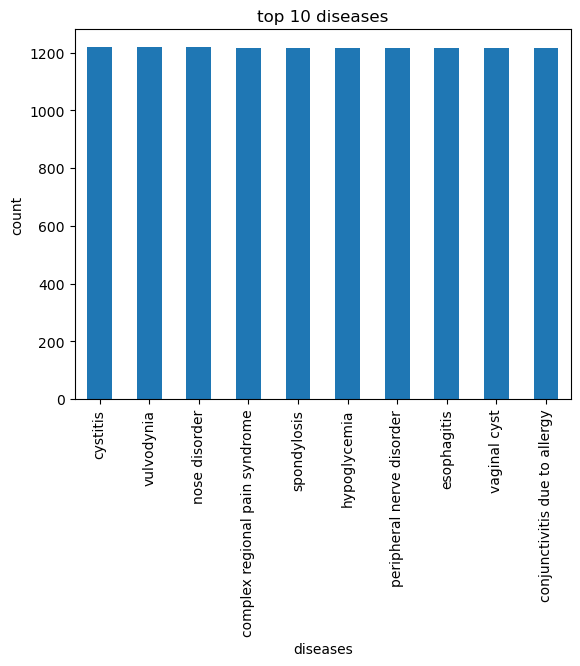

In [32]:
y.value_counts().head(10).plot(kind='bar')
plt.title("top 10 diseases")
plt.xlabel("diseases")
plt.ylabel("count")
plt.show()

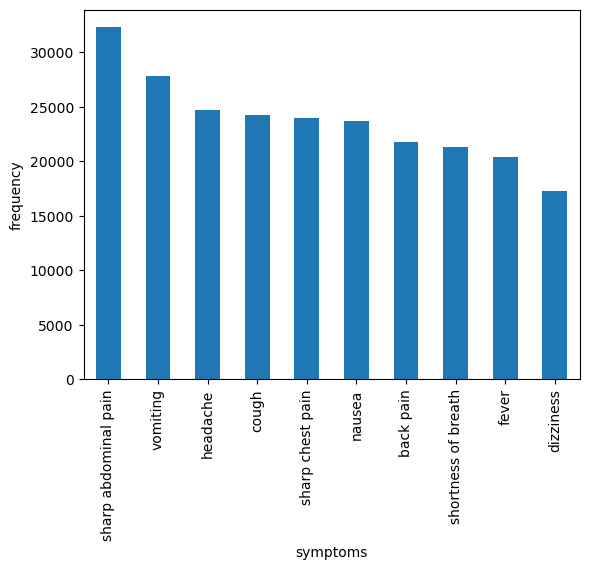

In [33]:
# SYMPTOM FREQUENCY#
sc=x.sum().sort_values(ascending=False)
sc.head(10).plot(kind='bar')
plt.xlabel("symptoms")
plt.ylabel("frequency")
plt.show()

Correlation Heatmap


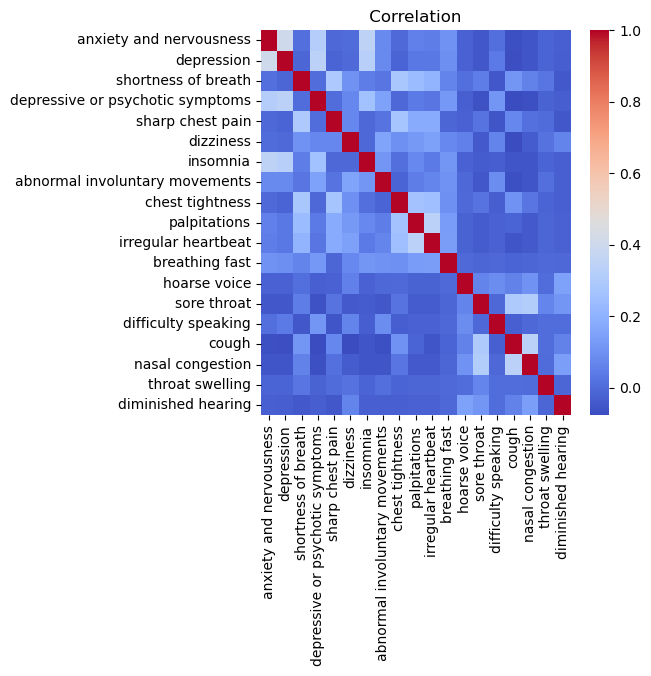

In [34]:
import seaborn as sns
plt.figure(figsize=(5,5))
sns.heatmap(df.iloc[:,1:20].corr(),cmap="coolwarm")
plt.title(" Correlation ")
plt.show()


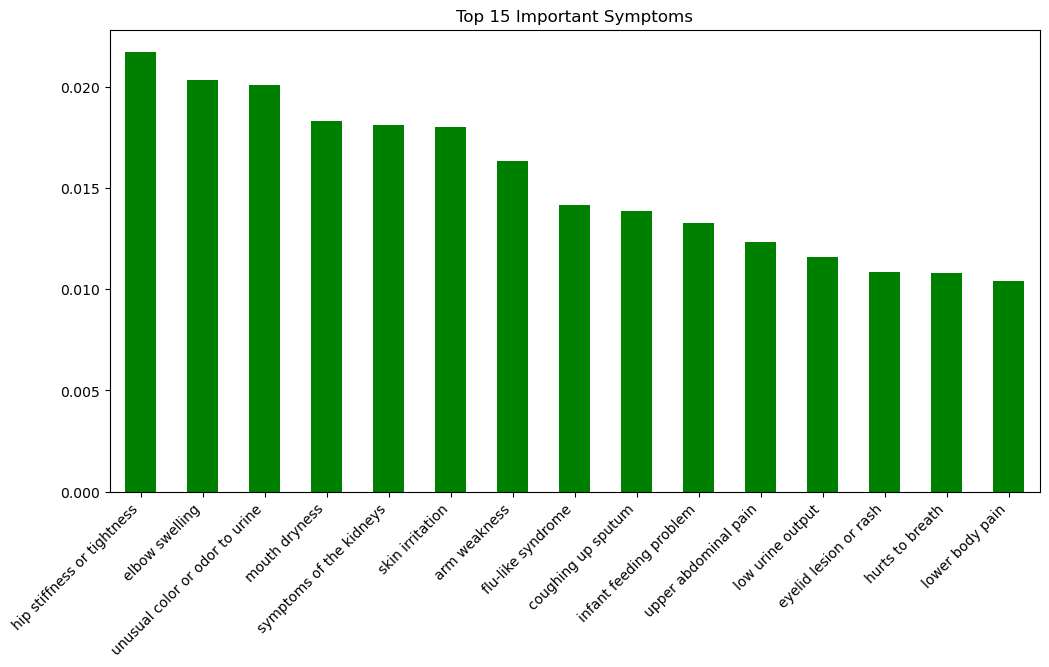

In [35]:
from sklearn.ensemble import RandomForestClassifier

df_sample = df.sample(n=50000, random_state=42)

X_sample = df_sample.drop("diseases", axis=1)
y_sample = df_sample["diseases"]

rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_sample, y_sample)
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X_sample.columns)

plt.figure(figsize=(12,6))
feat_importances.sort_values(ascending=False).head(15).plot(kind='bar', color='green')
plt.title("Top 15 Important Symptoms")
plt.xticks(rotation=45, ha='right')
plt.show()

Random Forest Accuracy: 17.30%
Extra Trees Accuracy: 13.25%
Logistic Regression Accuracy: 24.60%
KNN Accuracy: 18.75%
Gradient Boosting Accuracy: 14.25%


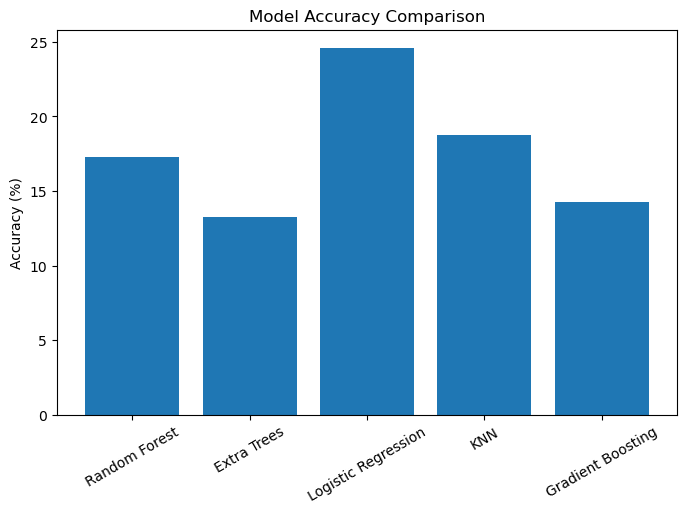

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# --------------------------
# 1️⃣ Load Dataset
# --------------------------
df = pd.read_csv("data.csv")

# --------------------------
# 2️⃣ Take Smaller Sample (FAST)
# --------------------------
df_sample = df.sample(n=10000, random_state=42)

# --------------------------
# 3️⃣ Feature Selection (Top 50)
# --------------------------
X_temp = df_sample.drop("diseases", axis=1)
y_temp = df_sample["diseases"]

rf_temp = RandomForestClassifier(n_estimators=20, max_depth=8, random_state=42)
rf_temp.fit(X_temp, y_temp)

importances = rf_temp.feature_importances_
feat_importances = pd.Series(importances, index=X_temp.columns)

top_features = feat_importances.sort_values(ascending=False).head(50).index

# Final dataset
X = df_sample[top_features]
y = df_sample["diseases"]

# --------------------------
# 4️⃣ Train-Test Split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------
# 5️⃣ Scaling (for KNN & Logistic)
# --------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------
# 6️⃣ Models
# --------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=30, max_depth=8, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=30, max_depth=8, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=300),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=30, max_depth=3)
}

results = {}

# --------------------------
# 7️⃣ Train & Evaluate
# --------------------------
for name, model in models.items():
    if name in ["KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")

# --------------------------
# 8️⃣ Plot Results
# --------------------------
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [v*100 for v in results.values()])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

In [37]:
import numpy as np

# Train best model (Logistic Regression)
best_model = LogisticRegression(max_iter=300)
best_model.fit(X_train_scaled, y_train)

# Predict probabilities
probs = best_model.predict_proba(X_test_scaled)

# Get top 3 predictions
top3 = np.argsort(probs, axis=1)[:, -3:]

# Convert index → disease names
classes = best_model.classes_

# Example: first patient
for i in range(5):
    print("Actual:", y_test.iloc[i])
    
    print("Top 3 Predictions:")
    for idx in reversed(top3[i]):
        print(classes[idx])
    print("------")

Actual: rheumatoid arthritis
Top 3 Predictions:
rheumatoid arthritis
injury to the arm
psoriasis
------
Actual: paroxysmal ventricular tachycardia
Top 3 Predictions:
panic disorder
paroxysmal ventricular tachycardia
ischemic heart disease
------
Actual: vaginal yeast infection
Top 3 Predictions:
spontaneous abortion
vaginal cyst
vaginitis
------
Actual: ganglion cyst
Top 3 Predictions:
ganglion cyst
injury to the leg
joint effusion
------
Actual: oral mucosal lesion
Top 3 Predictions:
spontaneous abortion
vaginal cyst
vaginitis
------


In [39]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(top_features, "features.pkl")

['features.pkl']